# Load Cached AnnData Objects

This notebook is now for working with the cached `.h5ad` files only. It does not convert Seurat `.rds` files and it should not remake AnnData files during normal analysis.

Current cached files:

- Shi 2019 paper QC: `$PROJECT_ROOT/results/python_anndata/shi_2019_paper_qc.h5ad`
- Varela DIV30: `$PROJECT_ROOT/results/python_anndata/varela_div30.h5ad`
- Varela DIV90: `$PROJECT_ROOT/results/python_anndata/varela_div90.h5ad`

If a source Seurat object changes, rebuild the cache with the Slurm template from a login-node terminal:

```bash
cd /home/elcrespo/Desktop/githubprojects/mge_organoid_pipeline
cp slurm_templates/08_convert_python_anndata.sbatch.template   /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/jobs/08_convert_python_anndata.sbatch
sbatch /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/jobs/08_convert_python_anndata.sbatch
```

The Slurm job skips existing current `.h5ad` files unless the template is changed to run with overwrite.

## Analysis Goal And Contract

Main goal: recreate and extend the published Shi/Varela organoid analysis in Python, starting from the cached AnnData objects and using the published findings as the reference point.

Working contract for this notebook:

- Start from cached `.h5ad` files only; do not remake Seurat conversions here.
- Preserve original metadata columns from the Seurat objects.
- Add new harmonized or derived columns with explicit names instead of overwriting originals.
- First reproduce published-facing views: dataset summaries, published labels, UMAPs, and marker patterns.
- Then run Python-native analyses such as QC summaries, marker scoring, clustering, and cross-dataset comparisons.
- Keep exploratory helper functions in the notebook until they are stable.
- Move stable helpers into `python_notebooks/src/mge_organoid_python/` only after the notebook logic is working and useful.

The notebook should remain the analysis narrative. Python modules should hold reusable mechanics once they have stabilized.

## Kernel And Path Setup

Use the `Python (mge-organoid-python)` kernel. This cell adds the repo-local Python package under `python_notebooks/src` so imports work from the notebook without installing the package into site-packages.

In [76]:
import os
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
candidate_roots = [cwd, cwd.parent]
if len(cwd.parents) >= 2:
    candidate_roots.append(cwd.parents[1])

for root in candidate_roots:
    src = root / "python_notebooks" / "src"
    if src.exists():
        sys.path.insert(0, str(src))
        repo_root = root
        break
else:
    raise RuntimeError("Could not locate python_notebooks/src from the current notebook directory")

repo_root

PosixPath('/home/elcrespo/Desktop/githubprojects/mge_organoid_pipeline')

In [77]:
import platform
import shutil

import matplotlib.pyplot as plt
import pandas as pd

from mge_organoid_python import (
    cached_h5ad_path,
    default_studies,
    load_cached_anndatas,
    missing_cached_h5ads,
    resolve_project_root,
    validate_source_paths,
)

project_root = resolve_project_root(os.environ.get("PROJECT_ROOT"))
studies = default_studies()
studies_by_id = {study.study_id: study for study in studies}

print("PROJECT_ROOT =", project_root)
for study in studies:
    print(f"{study.study_id}: {cached_h5ad_path(study, project_root=project_root)}")

PROJECT_ROOT = /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder
shi_2019_paper_qc: /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/results/python_anndata/shi_2019_paper_qc.h5ad
varela_div30: /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/results/python_anndata/varela_div30.h5ad
varela_div90: /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/results/python_anndata/varela_div90.h5ad


## Runtime Diagnostics

This confirms where the notebook kernel is running. Loading cached `.h5ad` files is allowed on a login node for light checks, especially with `backed="r"`. Do not run Seurat conversion from this notebook.

In [17]:
hostname = platform.node()
print("hostname:", hostname)
print("python:", sys.executable)
print("PROJECT_ROOT:", os.environ.get("PROJECT_ROOT"))
print("CONDA_DEFAULT_ENV:", os.environ.get("CONDA_DEFAULT_ENV"))
print("SLURM_JOB_ID:", os.environ.get("SLURM_JOB_ID"))
print("Rscript:", shutil.which("Rscript"))

if hostname.startswith("gl-login"):
    print("NOTE: This kernel is on a login node. Keep work light and use backed='r'.")
else:
    print("NOTE: This kernel is not on a login node.")

hostname: gl3088.arc-ts.umich.edu
python: /home/elcrespo/miniconda3/envs/mge-organoid-python/bin/python
PROJECT_ROOT: /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder
CONDA_DEFAULT_ENV: mge-organoid-python
SLURM_JOB_ID: 50317780
Rscript: /home/elcrespo/miniconda3/envs/mge-organoid-python/bin/Rscript
NOTE: This kernel is not on a login node.


## Confirm Inputs And Cached Outputs

The Seurat source path check tells you whether the canonical `.rds` files still exist. The cached output check is the important one for this notebook: all three `.h5ad` files must exist before analysis cells run.

In [78]:
source_missing = validate_source_paths(studies)
if source_missing:
    raise FileNotFoundError(f"Missing Seurat source files: {source_missing}")

cache_missing = missing_cached_h5ads(studies, project_root=project_root)
if cache_missing:
    raise FileNotFoundError(
        "Missing cached H5AD files: {}. Rebuild them with "
        "slurm_templates/08_convert_python_anndata.sbatch.template before running analysis.".format(cache_missing)
    )

cache_table = pd.DataFrame(
    [
        {
            "study_id": study.study_id,
            "label": study.label,
            "h5ad_path": str(cached_h5ad_path(study, project_root=project_root)),
            "size_gb": round(cached_h5ad_path(study, project_root=project_root).stat().st_size / 1024**3, 2),
        }
        for study in studies
    ]
)
cache_table

,study_id,label,h5ad_path,size_gb
0,shi_2019_paper_qc,Shi 2019 paper QC,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...,0.99
1,varela_div30,Varela DIV30,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...,4.48
2,varela_div90,Varela DIV90,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...,0.57


## Load Cached AnnData

The default is `backed="r"`, which opens each `.h5ad` read-only and avoids loading the full expression matrix into memory. This is the normal mode for inspection, metadata work, and UMAP plotting.

Use `backed=None` only when you intentionally need full in-memory AnnData for downstream methods that require modifying or densifying data.

In [19]:
adatas, reports = load_cached_anndatas(studies, project_root=project_root, backed="r")
reports_df = pd.DataFrame([report.as_dict() for report in reports])
reports_df

,study_id,label,h5ad_path,n_obs,n_vars,has_umap,n_obs_columns,n_var_columns
0,shi_2019_paper_qc,Shi 2019 paper QC,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...,56136,21191,True,14,1
1,varela_div30,Varela DIV30,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...,90631,18082,True,12,1
2,varela_div90,Varela DIV90,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...,22338,18082,True,14,1


## Analysis Roadmap

Initial notebook-first analysis sections:

1. AnnData inventory: shapes, layers, `.obs`, `.var`, `.obsm`, and available metadata.
2. Metadata harmonization: identify equivalent columns across Shi, DIV30, and DIV90 without overwriting originals.
3. QC and composition summaries: cells per dataset, sample, condition, and cluster label.
4. UMAP reproduction: original embeddings colored by published labels and key metadata.
5. Marker validation: known MGE/organoid marker genes on UMAPs, dot plots, and grouped summaries.
6. Python-native reanalysis: PCA/neighbors/Leiden/UMAP when needed, compared back to published labels.
7. Cross-dataset comparison: Shi vs Varela DIV30 vs Varela DIV90 using shared labels and marker programs.

Start by inspecting what metadata columns actually exist in each AnnData object before assuming a label name.

## AnnData Inventory Helpers

These helper functions stay in the notebook for now. Their job is to summarize what is actually present in each cached AnnData object before we harmonize metadata or reproduce published figures.

In [79]:
def adata_inventory(adatas):
    rows = []
    for study_id, adata in adatas.items():
        rows.append(
            {
                "study_id": study_id,
                "n_obs": adata.n_obs,
                "n_vars": adata.n_vars,
                "n_obs_columns": adata.obs.shape[1],
                "n_var_columns": adata.var.shape[1],
                "layers": ", ".join(adata.layers.keys()) if adata.layers else "",
                "obsm": ", ".join(adata.obsm.keys()) if adata.obsm else "",
                "has_X_umap": "X_umap" in adata.obsm,
            }
        )
    return pd.DataFrame(rows)


def obs_column_inventory(adatas):
    all_columns = sorted({column for adata in adatas.values() for column in adata.obs.columns})
    rows = []
    for column in all_columns:
        row = {"obs_column": column}
        for study_id, adata in adatas.items():
            row[study_id] = column in adata.obs.columns
        rows.append(row)
    return pd.DataFrame(rows)


def var_column_inventory(adatas):
    all_columns = sorted({column for adata in adatas.values() for column in adata.var.columns})
    rows = []
    for column in all_columns:
        row = {"var_column": column}
        for study_id, adata in adatas.items():
            row[study_id] = column in adata.var.columns
        rows.append(row)
    return pd.DataFrame(rows)


def categorical_obs_summary(adata, columns=None, max_unique=30):
    if columns is None:
        columns = list(adata.obs.columns)
    rows = []
    for column in columns:
        if column not in adata.obs.columns:
            continue
        series = adata.obs[column]
        nunique = int(series.nunique(dropna=True))
        if nunique <= max_unique or str(series.dtype) == "category":
            counts = series.astype("string").fillna("<NA>").value_counts(dropna=False)
            rows.append(
                {
                    "column": column,
                    "dtype": str(series.dtype),
                    "n_unique": nunique,
                    "top_values": "; ".join(f"{idx}: {value}" for idx, value in counts.head(10).items()),
                }
            )
    return pd.DataFrame(rows)


def numeric_obs_summary(adata, columns=None):
    if columns is None:
        columns = list(adata.obs.columns)
    rows = []
    for column in columns:
        if column not in adata.obs.columns:
            continue
        values = pd.to_numeric(adata.obs[column], errors="coerce")
        if values.notna().sum() == 0:
            continue
        rows.append(
            {
                "column": column,
                "n_non_missing": int(values.notna().sum()),
                "mean": float(values.mean()),
                "median": float(values.median()),
                "min": float(values.min()),
                "max": float(values.max()),
            }
        )
    return pd.DataFrame(rows)

## AnnData Inventory

This table confirms the basic object structure loaded from each cached `.h5ad` file.

In [80]:
inventory_df = adata_inventory(adatas)
inventory_df

,study_id,n_obs,n_vars,n_obs_columns,n_var_columns,layers,obsm,has_X_umap
0,shi_2019_paper_qc,56136,21191,21,1,,X_umap,True
1,varela_div30,90631,18082,12,1,,X_umap,True
2,varela_div90,22338,18082,14,1,,X_umap,True


## Metadata Column Comparison

This table shows which `.obs` columns are shared across studies and which are study-specific. It is the starting point for metadata harmonization.

In [81]:
obs_columns_df = obs_column_inventory(adatas)
obs_columns_df

,obs_column,shi_2019_paper_qc,varela_div30,varela_div90
0,CC.Difference,False,True,True
1,G2M.Score,False,True,True
2,Phase,False,True,True
3,RNA_snn_res.0.2,False,True,False
4,RNA_snn_res.0.5,False,False,True
5,RNA_snn_res.0.8,True,False,False
6,S.Score,False,True,True
7,barcode,True,False,False
8,cell_id,True,True,True
9,cluster_id,False,False,True


## Feature Metadata Columns

This checks `.var` columns. At this stage the converted objects keep feature IDs in `.var["feature_id"]`.

In [82]:
var_columns_df = var_column_inventory(adatas)
var_columns_df

,var_column,shi_2019_paper_qc,varela_div30,varela_div90
0,feature_id,True,True,True


## Categorical Metadata Summaries

These summaries identify cluster labels, sample labels, cell-cycle labels, and other low-cardinality metadata that can be used for published-figure reproduction.

In [83]:
for study_id, adata in adatas.items():
    print(f"\n## {study_id}")
    display(categorical_obs_summary(adata))


## shi_2019_paper_qc


,column,dtype,n_unique,top_values
0,orig.ident,category,1,Shi2019: 56136
1,nCount_RNA,category,8555,2170: 35; 2031: 35; 2092: 34; 2286: 33; 1903: ...
2,nFeature_RNA,category,2914,1053: 88; 1014: 86; 1032: 82; 1048: 81; 1061: ...
3,raw_cell_id,category,56090,GATCGATCAATTGCTG-GW12_02: 2; TGCCCTATCACATGCA-...
4,has_duplicated_raw_cell_id,category,2,FALSE: 56044; TRUE: 92
5,study_id,category,1,shi_2019: 56136
6,week_label,category,6,<NA>: 16905; GW12_02: 10854; GW12_01: 6704; GW...
7,week_numeric,category,5,12: 17558; <NA>: 16905; 16: 6179; 13: 5426; 9:...
8,barcode,category,55251,GAAATGACACTATCTT: 3; GCGACCAGTGACTCAT: 3; TTGC...
9,percent.mt,category,1,0: 56136



## varela_div30


,column,dtype,n_unique,top_values
0,orig.ident,category,6,9583-MW-6: 22528; 9583-MW-5: 22230; 9583-MW-3:...
1,nCount_RNA,category,19508,7553: 25; 7071: 25; 7173: 24; 6948: 24; 6563: ...
2,nFeature_RNA,category,6542,3926: 52; 3867: 51; 3963: 51; 3917: 51; 3821: ...
3,percent.mt,category,69076,0: 861; 0.127226463104326: 14; 0.1226993865030...
4,Phase,category,3,G1: 61396; S: 18707; G2M: 10528
5,old.ident,category,8,9583-MW-6: 22528; 9583-MW-5: 22230; 9583-MW-3:...
6,RNA_snn_res.0.2,category,7,0: 19148; 1: 18907; 2: 17287; 3: 15932; 4: 137...
7,seurat_clusters,category,7,0: 19148; 1: 18907; 2: 17287; 3: 15932; 4: 137...



## varela_div90


,column,dtype,n_unique,top_values
0,orig.ident,category,6,10496-MW-4: 6314; 10496-MW-6: 4850; 10496-MW-2...
1,nCount_RNA,category,7315,1540: 19; 1448: 17; 1443: 16; 1812: 16; 1437: ...
2,nFeature_RNA,category,4287,1251: 23; 1125: 23; 1242: 22; 1109: 22; 1166: ...
3,percent.mt,category,14978,0: 2265; 0.301204819277108: 11; 0.161290322580...
4,S.Score,category,22336,-0.065849128465105: 2; -0.00842015694178003: 2...
5,Phase,category,3,G1: 9845; S: 7422; G2M: 5071
6,old.ident,category,6,10496-MW-4: 6314; 10496-MW-6: 4850; 10496-MW-2...
7,RNA_snn_res.0.5,category,13,0: 3601; 1: 3548; 2: 3503; 3: 2283; 4: 1987; 5...
8,seurat_clusters,category,13,0: 3601; 1: 3548; 2: 3503; 3: 2283; 4: 1987; 5...
9,cluster_id,category,13,0: 3601; 1: 3548; 2: 3503; 3: 2283; 4: 1987; 5...


## Numeric Metadata Summaries

These summaries check available QC-like numeric columns such as counts, detected features, mitochondrial percentage, and cell-cycle scores.

In [84]:
for study_id, adata in adatas.items():
    print(f"\n## {study_id}")
    display(numeric_obs_summary(adata))


## shi_2019_paper_qc


,column,n_non_missing,mean,median,min,max
0,nCount_RNA,56136,3764.017921,3013.0,1086.0,14782.00000
1,nFeature_RNA,56136,1545.567194,1344.0,801.0,3987.00000
2,week_numeric,39231,13.103490,12.0,9.0,18.00000
3,percent.mt,56136,0.000000,0.0,0.0,0.00000
4,percent.hb,56136,0.004214,0.0,0.0,0.18018
5,RNA_snn_res.0.8,56136,5.635813,4.0,0.0,24.00000
6,seurat_clusters,56136,5.635813,4.0,0.0,24.00000
7,shi_gestational_week,56136,14.578043,13.0,9.0,18.00000



## varela_div30


,column,n_non_missing,mean,median,min,max
0,nCount_RNA,90631,9447.091591,7971.000000,1819.000000,29980.000000
1,nFeature_RNA,90631,4391.538977,4169.000000,1501.000000,8508.000000
2,percent.mt,90631,0.298288,0.174246,0.000000,4.954128
3,S.Score,90631,-0.012011,-0.077673,-0.392306,1.242907
4,G2M.Score,90631,-0.029538,-0.128385,-0.403523,2.000255
5,CC.Difference,90631,0.017527,0.040634,-2.022335,1.103949
6,RNA_snn_res.0.2,90631,2.116605,2.000000,0.000000,7.000000
7,seurat_clusters,90631,2.116605,2.000000,0.000000,7.000000



## varela_div90


,column,n_non_missing,mean,median,min,max
0,nCount_RNA,22338,3476.726430,2724.000000,547.000000,12317.000000
1,nFeature_RNA,22338,2246.493733,1990.000000,501.000000,4999.000000
2,percent.mt,22338,0.356753,0.223913,0.000000,4.887218
3,S.Score,22338,-0.004669,-0.017039,-0.193447,1.258934
4,G2M.Score,22338,-0.011870,-0.026421,-0.177718,2.199600
5,CC.Difference,22338,0.007201,0.008860,-2.133667,0.969127
6,RNA_snn_res.0.5,22338,3.589399,3.000000,0.000000,12.000000
7,seurat_clusters,22338,3.589399,3.000000,0.000000,12.000000
8,cluster_id,22338,3.589399,3.000000,0.000000,12.000000


## Shi 2019 Figure Reproduction Track

This section focuses only on the Shi dataset. The immediate goal is to recreate the figure ingredients available in the cached AnnData object: original UMAP coordinates, gestational-week metadata, Seurat clusters, and marker-gene expression.

Current limitation: this cached Shi object has numeric clusters but does not yet include a published cell-type label column. Until we import or reconstruct those labels, cluster-number UMAPs and marker expression are the most faithful starting point.

In [85]:
shi = adatas["shi_2019_paper_qc"]
shi_cluster_col = "seurat_clusters"
shi_sample_col = "shi_sample_id"
shi_week_col = "shi_gestational_week"
shi_region_col = "shi_region"
shi_original_week_col = "week_label"
shi_original_week_numeric_col = "week_numeric"

# Reconstruct the 9-sample design explicitly. These are derived columns;
# original columns such as week_label and week_numeric are preserved.
sample_ids = shi.obs_names.astype("string").str.extract(
    r"-(GW09|GW12_01|GW12_02|GW13|GW16|GW18_01|GW18_02_MGE|GW18_02_CGE|GW18_02_LGE)(?:_dup\d+)?$"
)[0]
shi.obs[shi_sample_col] = pd.Series(sample_ids.to_numpy(), index=shi.obs_names).astype("category")
shi.obs[shi_week_col] = shi.obs[shi_sample_col].astype("string").str.extract(r"GW(\d+)")[0].astype("float").astype("Int64")
shi.obs[shi_region_col] = shi.obs[shi_sample_col].astype("string").str.extract(r"GW18_02_(MGE|CGE|LGE)$")[0].fillna("not_split").astype("category")

print(shi)
print("obs columns:", list(shi.obs.columns))
print("var columns:", list(shi.var.columns))


AnnData object with n_obs × n_vars = 56136 × 21191 backed at '/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/results/python_anndata/shi_2019_paper_qc.h5ad'
    obs: 'cell_id', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'raw_cell_id', 'has_duplicated_raw_cell_id', 'study_id', 'week_label', 'week_numeric', 'barcode', 'percent.mt', 'percent.hb', 'RNA_snn_res.0.8', 'seurat_clusters', 'shi_sample_id', 'shi_gestational_week', 'shi_region', 'shi_published_major_type', 'shi_published_major_type_status', 'shi_major_type_plot', 'shi_major_type_display'
    var: 'feature_id'
    uns: 'conversion_manifest', 'seurat_assay', 'seurat_reduction', 'source_seurat_path'
    obsm: 'X_umap'
obs columns: ['cell_id', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'raw_cell_id', 'has_duplicated_raw_cell_id', 'study_id', 'week_label', 'week_numeric', 'barcode', 'percent.mt', 'percent.hb', 'RNA_snn_res.0.8', 'seurat_clusters', 'shi_sample_id', 'shi_gestational_week', 'shi_region', 'shi_published_major_

### Shi Metadata Counts

These tables show the developmental time points and cluster sizes available for reproducing Shi-facing UMAP and composition panels.

In [86]:
shi_sample_counts = shi.obs[shi_sample_col].astype("string").fillna("<NA>").value_counts().rename_axis(shi_sample_col).reset_index(name="n_cells")
shi_week_counts = shi.obs[shi_week_col].astype("string").fillna("<NA>").value_counts().rename_axis(shi_week_col).reset_index(name="n_cells")
shi_region_counts = shi.obs[shi_region_col].astype("string").fillna("<NA>").value_counts().rename_axis(shi_region_col).reset_index(name="n_cells")
shi_cluster_counts = shi.obs[shi_cluster_col].astype("string").value_counts().rename_axis(shi_cluster_col).reset_index(name="n_cells")

display(shi_sample_counts)
display(shi_week_counts)
display(shi_region_counts)
display(shi_cluster_counts)


,shi_sample_id,n_cells
0,GW12_02,10854
1,GW12_01,6704
2,GW18_02_LGE,6504
3,GW16,6179
4,GW18_02_CGE,5972
5,GW13,5426
6,GW09,5251
7,GW18_01,4817
8,GW18_02_MGE,4429


,shi_gestational_week,n_cells
0,18,21722
1,12,17558
2,16,6179
3,13,5426
4,9,5251


,shi_region,n_cells
0,not_split,39231
1,LGE,6504
2,CGE,5972
3,MGE,4429


,seurat_clusters,n_cells
0,0,8399
1,1,6262
2,2,6082
3,3,4818
4,4,3717
5,5,3645
6,6,3394
7,7,2787
8,8,2587
9,9,2414


### Shi Cluster By Sample Composition

This table asks whether clusters are evenly distributed across the 9 samples or enriched in particular samples. The separate gestational-week and region columns remain available for broader summaries.


In [87]:
shi_cluster_sample_counts = pd.crosstab(
    shi.obs[shi_cluster_col].astype("string"),
    shi.obs[shi_sample_col].astype("string").fillna("<NA>"),
)
shi_cluster_sample_fraction = shi_cluster_sample_counts.div(shi_cluster_sample_counts.sum(axis=1), axis=0)

shi_cluster_sample_counts


shi_sample_id,GW09,GW12_01,GW12_02,GW13,GW16,GW18_01,GW18_02_CGE,GW18_02_LGE,GW18_02_MGE
seurat_clusters,,,,,,,,,
0,3,544,65,623,1670,1615,2068,1662,149
1,335,970,938,1859,1463,479,93,62,63
10,1257,196,515,4,1,0,0,1,5
11,8,116,21,136,371,167,207,456,72
12,131,179,244,227,103,74,136,161,198
13,255,171,644,72,22,0,19,10,17
14,0,4,0,1,596,130,2,397,39
15,251,1,850,2,0,0,0,0,0
16,38,65,37,57,161,247,161,32,105


In [88]:
shi_cluster_sample_fraction.round(3)


shi_sample_id,GW09,GW12_01,GW12_02,GW13,GW16,GW18_01,GW18_02_CGE,GW18_02_LGE,GW18_02_MGE
seurat_clusters,,,,,,,,,
0,0.000,0.065,0.008,0.074,0.199,0.192,0.246,0.198,0.018
1,0.053,0.155,0.150,0.297,0.234,0.076,0.015,0.010,0.010
10,0.635,0.099,0.260,0.002,0.001,0.000,0.000,0.001,0.003
11,0.005,0.075,0.014,0.088,0.239,0.107,0.133,0.293,0.046
12,0.090,0.123,0.168,0.156,0.071,0.051,0.094,0.111,0.136
13,0.211,0.141,0.532,0.060,0.018,0.000,0.016,0.008,0.014
14,0.000,0.003,0.000,0.001,0.510,0.111,0.002,0.340,0.033
15,0.227,0.001,0.770,0.002,0.000,0.000,0.000,0.000,0.000
16,0.042,0.072,0.041,0.063,0.178,0.274,0.178,0.035,0.116


### Shi Supplemental Tables

The downloaded Shi et al. supplemental tables are stored under `PROJECT_ROOT/reference/shi_2021_tables_s2_to_s9`. Table S2 contains published UMAP coordinates and major cell-type labels for Fig. 1B. Table S3 contains differentially expressed genes among major cell types and is immediately useful for marker-based figure recreation.

Important: Table S2 cell IDs are not directly identical to this cached Shi AnnData object, so do not merge the major-type labels into `.obs` until we define and validate a safe join strategy.

In [89]:
shi_reference_dir = project_root / "reference" / "shi_2021_tables_s2_to_s9"
shi_table_s2_path = shi_reference_dir / "science.abj6641_table_s2.xlsx"
shi_table_s3_path = shi_reference_dir / "science.abj6641_table_s3.xlsx"

print("Table S2 exists:", shi_table_s2_path.exists(), shi_table_s2_path)
print("Table S3 exists:", shi_table_s3_path.exists(), shi_table_s3_path)

Table S2 exists: True /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/reference/shi_2021_tables_s2_to_s9/science.abj6641_table_s2.xlsx
Table S3 exists: True /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/reference/shi_2021_tables_s2_to_s9/science.abj6641_table_s3.xlsx


In [90]:
shi_s2 = pd.read_excel(shi_table_s2_path, sheet_name="UMAP coordinates", header=1)
shi_s3 = pd.read_excel(shi_table_s3_path, sheet_name="Major type DEGs", header=1)

print("Table S2 shape:", shi_s2.shape)
print("Table S2 columns:", list(shi_s2.columns))
print("Table S3 shape:", shi_s3.shape)
print("Table S3 columns:", list(shi_s3.columns))

display(shi_s2.head())
display(shi_s3.head())

Table S2 shape: (56412, 5)
Table S2 columns: ['Cells', 'UMAP-X', 'UMAP-Y', 'UMAP-Z', 'Major types']
Table S3 shape: (999, 8)
Table S3 columns: ['order', 'p_val', 'avg_logFC', 'pct.1', 'pct.2', 'p_val_adj', 'cluster', 'gene']


,Cells,UMAP-X,UMAP-Y,UMAP-Z,Major types
0,AAACCTGAGATGTAAC-1,-5.634853,1.208610,1.548897,MGE
1,AAACCTGAGCTCAACT-1,-5.361302,0.218759,-0.070487,MGE
2,AAACCTGAGTACTTGC-1,6.327639,4.551618,-1.106218,progenitor
3,AAACCTGAGTAGCGGT-1,6.287843,1.988571,5.438268,Excitatory IPC
4,AAACCTGAGTGCTGCC-1,-5.237712,1.046611,2.226487,Thalamic neurons


,order,p_val,avg_logFC,pct.1,pct.2,p_val_adj,cluster,gene
0,1,0.0,1.420564,0.233,0.074,0.0,MGE,SST
1,2,0.0,1.251286,0.698,0.226,0.0,MGE,PLS3
2,3,0.0,0.942155,0.341,0.036,0.0,MGE,LHX6
3,4,0.0,0.931069,0.566,0.255,0.0,MGE,CXCR4
4,5,0.0,0.880867,0.600,0.308,0.0,MGE,ARL4D


### Published Major Types And Marker Genes

Use these as the first published reference for reproducing Shi marker panels and for assigning biological meaning to our numeric clusters.

In [91]:
shi_s2_major_type_counts = shi_s2["Major types"].astype("string").value_counts().rename_axis("major_type").reset_index(name="n_cells")
shi_s3_top_markers = (
    shi_s3.sort_values(["cluster", "p_val_adj", "avg_logFC"], ascending=[True, True, False])
    .groupby("cluster", observed=True)
    .head(10)
    .loc[:, ["cluster", "gene", "avg_logFC", "pct.1", "pct.2", "p_val_adj"]]
)

display(shi_s2_major_type_counts)
display(shi_s3_top_markers)

,major_type,n_cells
0,MGE,15472
1,LGE,11866
2,progenitor,8036
3,CGE,7196
4,Thalamic neurons,4430
5,progenitor,4082
6,Excitatory neuron,3795
7,Excitatory IPC,1086
8,Microglia,244
9,OPC,166


,cluster,gene,avg_logFC,pct.1,pct.2,p_val_adj
100,CGE,SCGN,1.229646,0.428,0.048,0.0
101,CGE,CALB2,1.142435,0.375,0.069,0.0
102,CGE,DLX6-AS1,0.963749,0.990,0.700,0.0
103,CGE,TCF4,0.867985,0.940,0.663,0.0
104,CGE,PDZRN3,0.866416,0.419,0.140,0.0
...,...,...,...,...,...,...
303,progenitor,NUSAP1,1.657564,0.655,0.054,0.0
304,progenitor,UBE2C,1.618539,0.609,0.101,0.0
305,progenitor,PTTG1,1.575050,0.649,0.099,0.0
306,progenitor,TUBA1B,1.531987,0.993,0.892,0.0


### Table S2 Join Status

This diagnostic checks whether Table S2 cell IDs can be directly mapped onto the cached Shi AnnData object. At present, the answer is no: Table S2 uses IDs such as `AAAC...-1`, while the cached AnnData object uses sample-suffixed IDs such as `AAAC...-GW09`. A partial barcode match exists, but it is not enough for a safe full merge.

In [92]:
shi_s2_barcodes = shi_s2["Cells"].astype("string").str.replace(r"-1$", "", regex=True)
join_diagnostics = pd.DataFrame(
    [
        {
            "comparison": "Table S2 Cells vs adata.obs['cell_id']",
            "n_matches": len(set(shi_s2["Cells"].astype(str)) & set(shi.obs["cell_id"].astype(str))),
        },
        {
            "comparison": "Table S2 Cells vs adata.obs['raw_cell_id']",
            "n_matches": len(set(shi_s2["Cells"].astype(str)) & set(shi.obs["raw_cell_id"].astype(str))),
        },
        {
            "comparison": "Table S2 barcode prefix vs adata.obs['barcode']",
            "n_matches": len(set(shi_s2_barcodes.astype(str)) & set(shi.obs["barcode"].astype(str))),
        },
    ]
)
join_diagnostics

,comparison,n_matches
0,Table S2 Cells vs adata.obs['cell_id'],0
1,Table S2 Cells vs adata.obs['raw_cell_id'],0
2,Table S2 barcode prefix vs adata.obs['barcode'],5251


### Shi Plotting Helpers

These are notebook-local plotting helpers for reproducing Shi UMAP panels. If they remain useful after a few iterations, move them into a Python module.

In [93]:
import numpy as np
from scipy import sparse


def gene_lookup(adata):
    return {str(gene).upper(): str(gene) for gene in adata.var_names}


def gene_expression_vector(adata, gene):
    lookup = gene_lookup(adata)
    resolved = lookup.get(gene.upper())
    if resolved is None:
        raise KeyError(f"{gene} not found in adata.var_names")
    x = adata[:, resolved].X
    if sparse.issparse(x):
        x = x.toarray()
    return np.asarray(x).reshape(-1), resolved


def plot_shi_umap_by_obs(column, title=None, s=2, alpha=0.65, legend=True):
    if column not in shi.obs:
        raise KeyError(f"{column} not found in shi.obs")
    umap = shi.obsm["X_umap"]
    values = shi.obs[column].astype("string").fillna("<NA>")
    categories = pd.Categorical(values)
    fig, ax = plt.subplots(figsize=(6, 5))
    scatter = ax.scatter(umap[:, 0], umap[:, 1], c=categories.codes, s=s, alpha=alpha, cmap="tab20")
    ax.set_title(title or f"Shi 2019: {column}")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_aspect("equal", adjustable="box")
    if legend:
        handles, _ = scatter.legend_elements(num=None)
        labels = list(categories.categories)
        ax.legend(handles[: len(labels)], labels, title=column, bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=4)
    return fig, ax


def plot_shi_gene_umap(gene, s=2, alpha=0.75, cmap="viridis"):
    expr, resolved = gene_expression_vector(shi, gene)
    umap = shi.obsm["X_umap"]
    fig, ax = plt.subplots(figsize=(6, 5))
    scatter = ax.scatter(umap[:, 0], umap[:, 1], c=expr, s=s, alpha=alpha, cmap=cmap)
    ax.set_title(f"Shi 2019: {resolved}")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_aspect("equal", adjustable="box")
    fig.colorbar(scatter, ax=ax, label="expression")
    return fig, ax

### Safe Table S2 Major-Type Mapping

The Table S2 numeric suffixes can be translated to the 9-sample IDs in this AnnData object. This recovers nearly all published major-type labels. A small set of duplicated GW12_02 barcodes is ambiguous because multiple Table S2 rows map to the same base cell ID with different major-type labels. Those cells are flagged and left unassigned rather than guessed.


In [94]:
shi_s2_suffix_to_sample_id = {
    "1": "GW09",
    "2": "GW12_01",
    "3": "GW13",
    "4": "GW16",
    "5": "GW18_01",
    "6": "GW18_02_CGE",
    "7": "GW18_02_LGE",
    "8": "GW18_02_MGE",
    "9": "GW12_02",
    "10": "GW12_02",
    "11": "GW12_02",
}

shi_s2_mapped = shi_s2.copy()
shi_s2_mapped["barcode"] = shi_s2_mapped["Cells"].astype("string").str.replace(r"-\d+$", "", regex=True)
shi_s2_mapped["s2_suffix"] = shi_s2_mapped["Cells"].astype("string").str.extract(r"-(\d+)$")[0]
shi_s2_mapped["shi_sample_id"] = shi_s2_mapped["s2_suffix"].map(shi_s2_suffix_to_sample_id)
shi_s2_mapped["candidate_cell_id"] = shi_s2_mapped["barcode"] + "-" + shi_s2_mapped["shi_sample_id"]
shi_s2_mapped["published_major_type_clean"] = shi_s2_mapped["Major types"].astype("string").str.strip()

candidate_counts = shi_s2_mapped["candidate_cell_id"].value_counts(dropna=False)
shi_s2_mapped["candidate_is_unique"] = shi_s2_mapped["candidate_cell_id"].map(candidate_counts).eq(1)
shi_obs_ids = pd.Index(shi.obs_names.astype("string"))
shi_s2_mapped["candidate_in_adata"] = shi_s2_mapped["candidate_cell_id"].isin(set(shi_obs_ids.astype(str)))

safe_major_type_map = (
    shi_s2_mapped.loc[shi_s2_mapped["candidate_is_unique"] & shi_s2_mapped["candidate_in_adata"]]
    .set_index("candidate_cell_id")["published_major_type_clean"]
)

shi.obs["shi_published_major_type"] = pd.Series(shi.obs_names.astype("string"), index=shi.obs_names).map(safe_major_type_map).astype("category")
shi.obs["shi_published_major_type_status"] = "unmapped"
shi.obs.loc[shi.obs["shi_published_major_type"].notna(), "shi_published_major_type_status"] = "mapped_unique"
shi.obs.loc[shi.obs["has_duplicated_raw_cell_id"].astype("string").eq("TRUE"), "shi_published_major_type_status"] = "ambiguous_duplicate_barcode"
shi.obs["shi_published_major_type_status"] = shi.obs["shi_published_major_type_status"].astype("category")

mapping_summary = pd.DataFrame(
    [
        {"metric": "Table S2 rows", "value": len(shi_s2_mapped)},
        {"metric": "AnnData cells", "value": shi.n_obs},
        {"metric": "unique mapped AnnData cells", "value": int(shi.obs["shi_published_major_type"].notna().sum())},
        {"metric": "ambiguous duplicate-barcode cells", "value": int((shi.obs["shi_published_major_type_status"] == "ambiguous_duplicate_barcode").sum())},
        {"metric": "unmapped non-duplicate cells", "value": int((shi.obs["shi_published_major_type_status"] == "unmapped").sum())},
    ]
)

mapping_summary


,metric,value
0,Table S2 rows,56412
1,AnnData cells,56136
2,unique mapped AnnData cells,56044
3,ambiguous duplicate-barcode cells,92
4,unmapped non-duplicate cells,0


In [95]:
shi_published_major_type_counts = (
    shi.obs["shi_published_major_type"]
    .astype("string")
    .fillna("<unassigned>")
    .value_counts()
    .rename_axis("shi_published_major_type")
    .reset_index(name="n_cells")
)
shi_published_major_type_counts

,shi_published_major_type,n_cells
0,MGE,15335
1,progenitor,12095
2,LGE,11780
3,CGE,7126
4,Thalamic neurons,4400
5,Excitatory neuron,3779
6,Excitatory IPC,1085
7,Microglia,240
8,OPC,165
9,<unassigned>,92


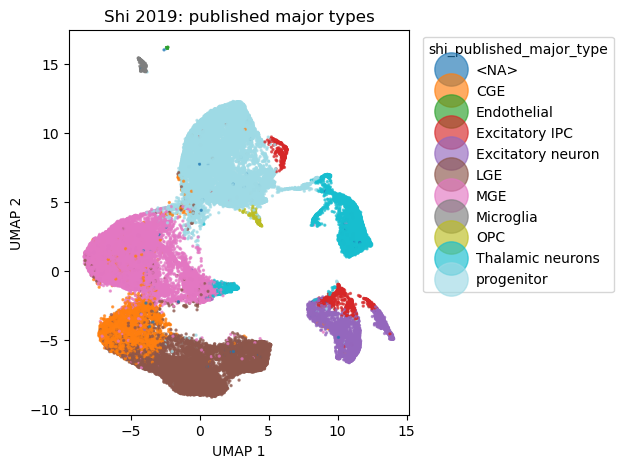

In [96]:
plot_shi_umap_by_obs("shi_published_major_type", title="Shi 2019: published major types", s=2, alpha=0.65)
plt.show()

### Recreate Shi Major Cell-Class UMAP

This is the first target published-style panel: the Shi UMAP colored by the major cell classes from Table S2. Labels are cleaned by stripping leading spaces, but the original Table S2 labels remain in `shi_s2`.

In [97]:
shi_major_type_order = [
    "MGE",
    "LGE",
    "CGE",
    "progenitor",
    "Thalamic neurons",
    "Excitatory neuron",
    "Excitatory IPC",
    "OPC",
    "Microglia",
    "Endothelial",
    "<unassigned>",
]

shi_major_type_palette = {
    "MGE": "#1f77b4",
    "LGE": "#ff7f0e",
    "CGE": "#2ca02c",
    "progenitor": "#9467bd",
    "Thalamic neurons": "#8c564b",
    "Excitatory neuron": "#d62728",
    "Excitatory IPC": "#e377c2",
    "OPC": "#17becf",
    "Microglia": "#7f7f7f",
    "Endothelial": "#bcbd22",
    "<unassigned>": "#d9d9d9",
}

shi.obs["shi_major_type_plot"] = (
    shi.obs["shi_published_major_type"]
    .astype("string")
    .fillna("<unassigned>")
)
shi.obs["shi_major_type_plot"] = pd.Categorical(
    shi.obs["shi_major_type_plot"],
    categories=[label for label in shi_major_type_order if label in set(shi.obs["shi_major_type_plot"].astype(str))],
    ordered=True,
)

shi_major_type_counts = (
    shi.obs["shi_major_type_plot"]
    .astype("string")
    .value_counts()
    .rename_axis("major_cell_class")
    .reset_index(name="n_cells")
)
shi_major_type_counts["fraction"] = shi_major_type_counts["n_cells"] / shi.n_obs
shi_major_type_counts

,major_cell_class,n_cells,fraction
0,MGE,15335,0.273176
1,progenitor,12095,0.215459
2,LGE,11780,0.209848
3,CGE,7126,0.126942
4,Thalamic neurons,4400,0.078381
5,Excitatory neuron,3779,0.067319
6,Excitatory IPC,1085,0.019328
7,Microglia,240,0.004275
8,OPC,165,0.002939
9,<unassigned>,92,0.001639


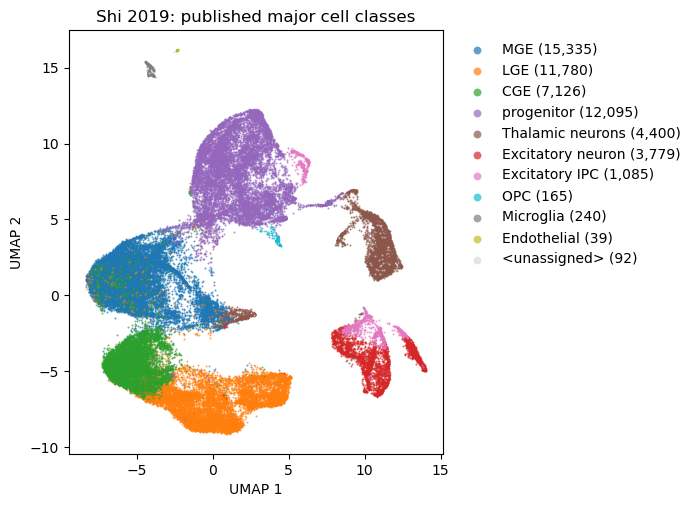

In [98]:
def plot_shi_major_type_umap(s=2, alpha=0.7):
    umap = shi.obsm["X_umap"]
    labels = shi.obs["shi_major_type_plot"].astype("string").fillna("<unassigned>")
    present_labels = [label for label in shi_major_type_order if label in set(labels)]

    fig, ax = plt.subplots(figsize=(7, 5.5))
    for label in present_labels:
        mask = labels.eq(label).to_numpy()
        ax.scatter(
            umap[mask, 0],
            umap[mask, 1],
            s=s,
            alpha=alpha,
            c=shi_major_type_palette.get(label, "#333333"),
            label=f"{label} ({mask.sum():,})",
            linewidths=0,
        )
    ax.set_title("Shi 2019: published major cell classes")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, markerscale=4)
    return fig, ax

plot_shi_major_type_umap()
plt.show()

### Major Cell-Class Composition By Sample

This table supports the next figure style: how each major cell class is distributed across the 9 Shi samples.

In [99]:
shi_major_type_by_sample_counts = pd.crosstab(
    shi.obs["shi_major_type_plot"].astype("string"),
    shi.obs[shi_sample_col].astype("string"),
).reindex(index=[label for label in shi_major_type_order if label in set(shi.obs["shi_major_type_plot"].astype("string"))])

shi_major_type_by_sample_fraction = shi_major_type_by_sample_counts.div(
    shi_major_type_by_sample_counts.sum(axis=1), axis=0
)

shi_major_type_by_sample_counts

shi_sample_id,GW09,GW12_01,GW12_02,GW13,GW16,GW18_01,GW18_02_CGE,GW18_02_LGE,GW18_02_MGE
shi_major_type_plot,,,,,,,,,
MGE,1564,1310,1518,1947,2110,2002,2165,1309,1410
LGE,1025,1425,1488,1063,1359,523,1008,2726,1163
CGE,86,477,463,532,1317,1439,1788,943,81
progenitor,1112,1333,2693,1828,713,647,1005,1053,1711
Thalamic neurons,205,1086,3108,0,1,0,0,0,0
Excitatory neuron,916,831,1020,3,553,107,1,305,43
Excitatory IPC,313,172,370,2,68,32,2,123,3
OPC,6,35,26,17,40,13,2,18,8
Microglia,17,27,71,22,14,53,0,27,9


In [100]:
shi_major_type_by_sample_fraction.round(3)

shi_sample_id,GW09,GW12_01,GW12_02,GW13,GW16,GW18_01,GW18_02_CGE,GW18_02_LGE,GW18_02_MGE
shi_major_type_plot,,,,,,,,,
MGE,0.102,0.085,0.099,0.127,0.138,0.131,0.141,0.085,0.092
LGE,0.087,0.121,0.126,0.090,0.115,0.044,0.086,0.231,0.099
CGE,0.012,0.067,0.065,0.075,0.185,0.202,0.251,0.132,0.011
progenitor,0.092,0.110,0.223,0.151,0.059,0.053,0.083,0.087,0.141
Thalamic neurons,0.047,0.247,0.706,0.000,0.000,0.000,0.000,0.000,0.000
Excitatory neuron,0.242,0.220,0.270,0.001,0.146,0.028,0.000,0.081,0.011
Excitatory IPC,0.288,0.159,0.341,0.002,0.063,0.029,0.002,0.113,0.003
OPC,0.036,0.212,0.158,0.103,0.242,0.079,0.012,0.109,0.048
Microglia,0.071,0.112,0.296,0.092,0.058,0.221,0.000,0.112,0.038


### Shi UMAP Reproduction Panels

These use the original UMAP coordinates from the converted Seurat object.

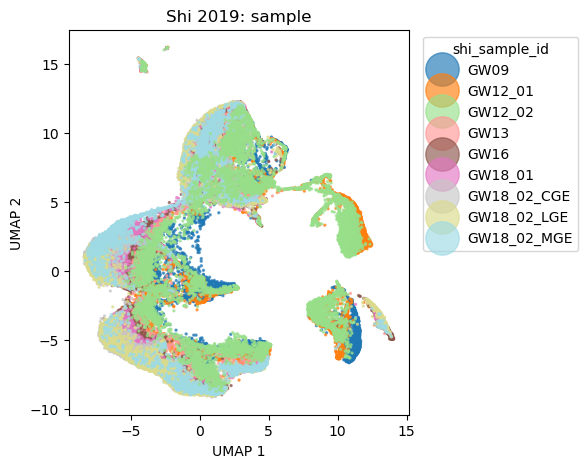

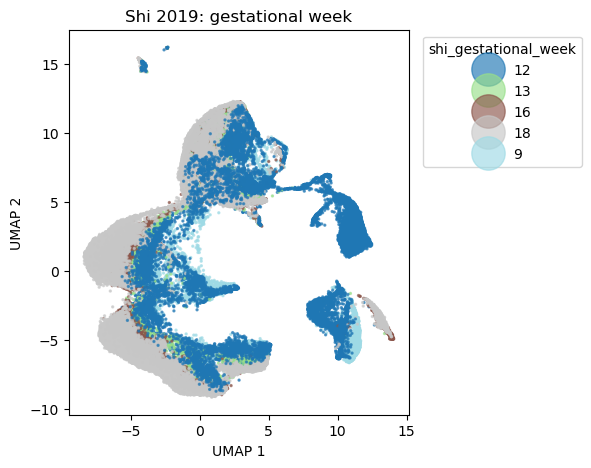

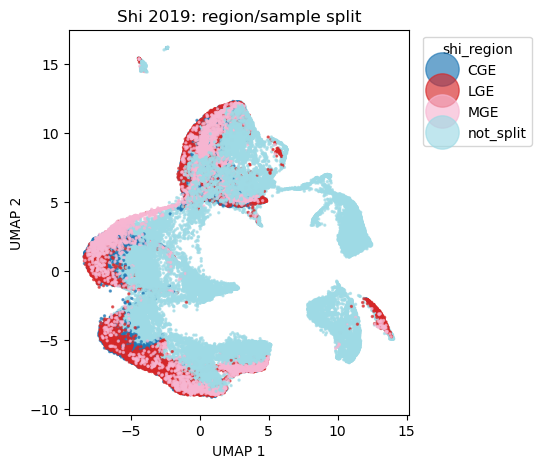

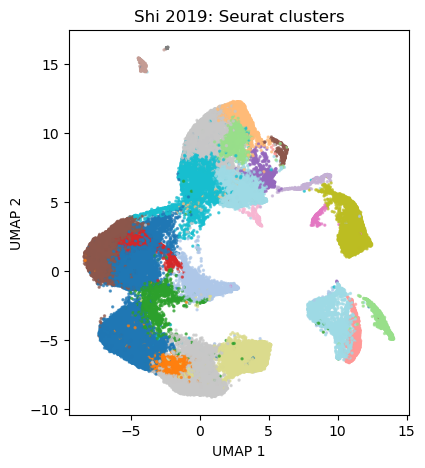

In [101]:
plot_shi_umap_by_obs(shi_sample_col, title="Shi 2019: sample")
plot_shi_umap_by_obs(shi_week_col, title="Shi 2019: gestational week")
plot_shi_umap_by_obs(shi_region_col, title="Shi 2019: region/sample split")
plot_shi_umap_by_obs(shi_cluster_col, title="Shi 2019: Seurat clusters", legend=False)
plt.show()


### Shi Marker Gene Panels

Candidate marker sets for early reproduction. These are starting points for matching published panels; refine the list once we anchor to the exact Shi figure panels and any published cluster annotations.

In [102]:
shi_marker_sets = {
    "regional_identity": ["FOXG1", "NKX2-1", "DLX1", "DLX2", "LHX6", "LHX8"],
    "gabaergic_neuron": ["GAD1", "GAD2", "SLC32A1", "DCX", "STMN2"],
    "progenitor_cell_cycle": ["SOX2", "VIM", "MKI67", "TOP2A", "EOMES"],
    "interneuron_subtype_candidates": ["SST", "NPY", "PVALB", "CRABP1", "ERBB4", "CXCR4"],
}

available_shi_markers = []
missing_shi_markers = []
lookup = gene_lookup(shi)
for group, genes in shi_marker_sets.items():
    for gene in genes:
        if gene.upper() in lookup:
            available_shi_markers.append({"group": group, "gene": gene, "resolved_gene": lookup[gene.upper()]})
        else:
            missing_shi_markers.append({"group": group, "gene": gene})

available_shi_markers_df = pd.DataFrame(available_shi_markers)
missing_shi_markers_df = pd.DataFrame(missing_shi_markers)

display(available_shi_markers_df)
display(missing_shi_markers_df)

,group,gene,resolved_gene
0,regional_identity,FOXG1,FOXG1
1,regional_identity,NKX2-1,NKX2-1
2,regional_identity,DLX1,DLX1
3,regional_identity,DLX2,DLX2
4,regional_identity,LHX6,LHX6
5,regional_identity,LHX8,LHX8
6,gabaergic_neuron,GAD1,GAD1
7,gabaergic_neuron,GAD2,GAD2
8,gabaergic_neuron,SLC32A1,SLC32A1
9,gabaergic_neuron,DCX,DCX


""


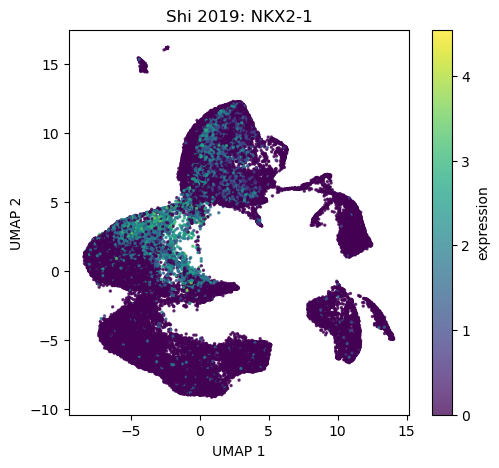

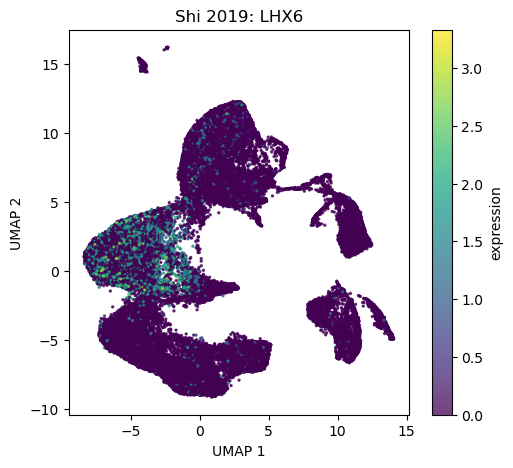

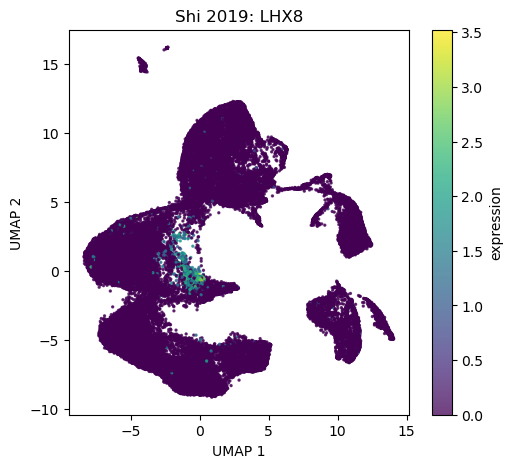

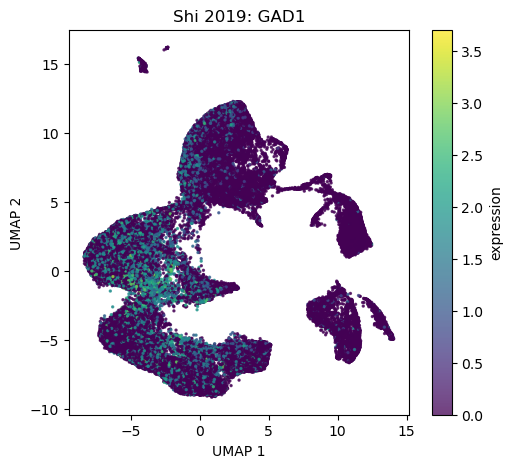

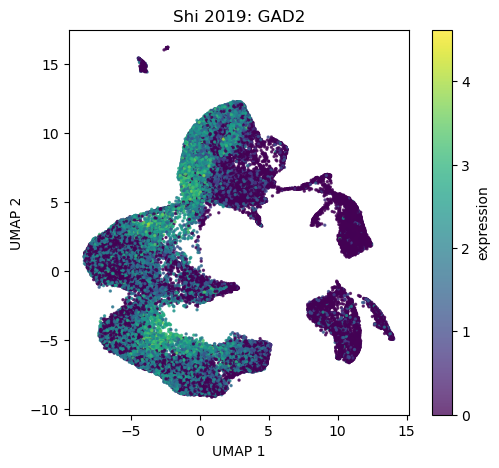

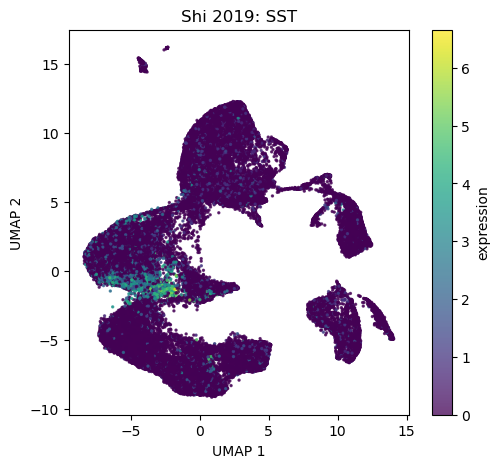

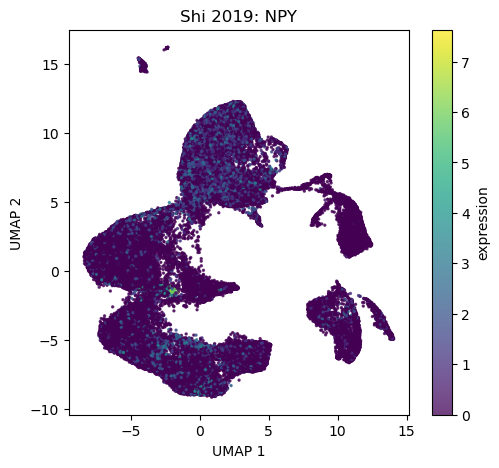

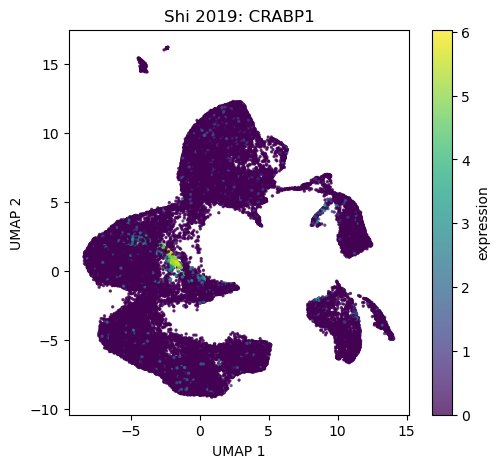

In [103]:
# Start with a small marker set so plots render quickly.
for gene in ["NKX2-1", "LHX6", "LHX8", "GAD1", "GAD2", "SST", "NPY", "CRABP1"]:
    if gene.upper() in gene_lookup(shi):
        plot_shi_gene_umap(gene)
plt.show()

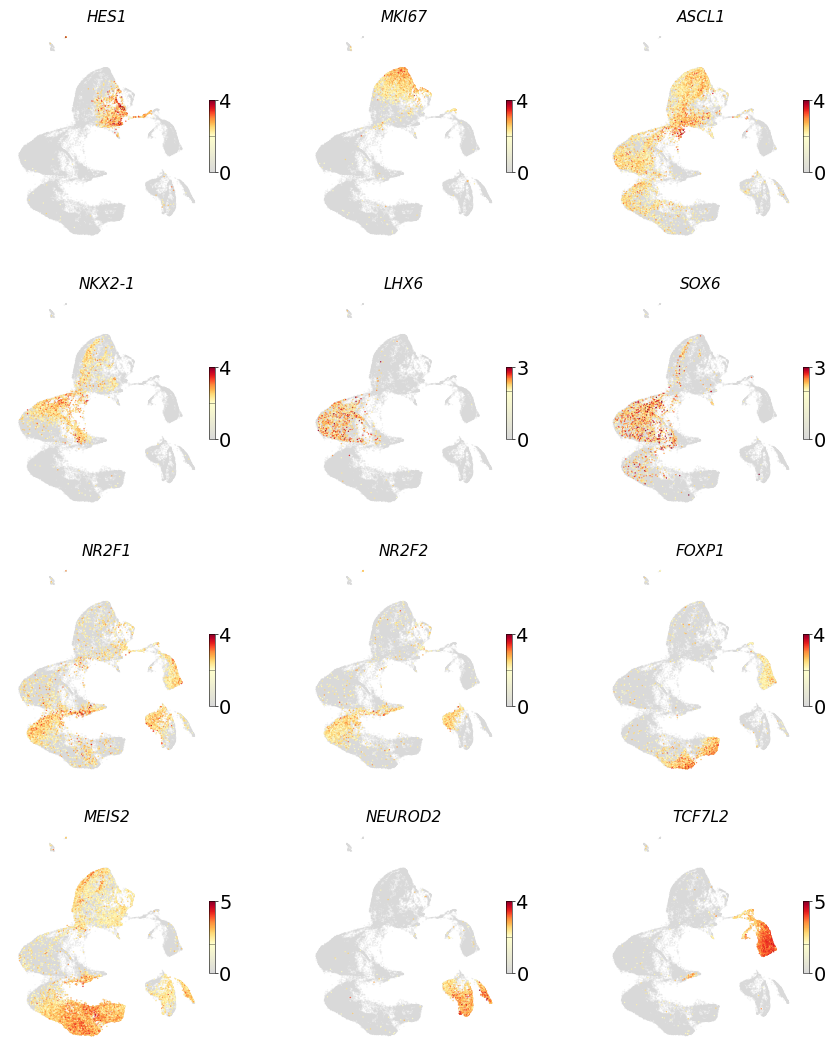

In [104]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import sparse
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


genes_to_plot = [
    "HES1", "MKI67", "ASCL1",
    "NKX2-1", "LHX6", "SOX6",
    "NR2F1", "NR2F2", "FOXP1",
    "MEIS2", "NEUROD2", "TCF7L2",
]


# This is the visual lower bound for colored expression.
# Increase it to suppress more weak log-normalized signal.
# Decrease it to show more low-level expression.
feature_vmin_expression = 2.0


def get_gene_expression(adata, gene):
    """Return expression vector for one gene from AnnData."""
    gene_lookup = {str(g).upper(): str(g) for g in adata.var_names}
    resolved_gene = gene_lookup.get(gene.upper())

    if resolved_gene is None:
        raise KeyError(f"{gene} not found in adata.var_names")

    x = adata[:, resolved_gene].X
    if sparse.issparse(x):
        x = x.toarray()

    return np.asarray(x).reshape(-1), resolved_gene


def rounded_vmax(expr, percentile=99, minimum=1):
    """Compute percentile-based vmax and round up to a whole number."""
    finite_expr = expr[np.isfinite(expr)]
    positive_expr = finite_expr[finite_expr > 0]

    if positive_expr.size == 0:
        return float(minimum)

    vmax = np.percentile(positive_expr, percentile)
    vmax = np.ceil(vmax)

    if vmax < minimum:
        vmax = minimum

    return float(vmax)


def make_thresholded_colorbar_cmap(
    expression_cmap,
    background_color="#d9d9d9",
    n_colors=256,
    gray_fraction=0.18,
):
    """
    Build a smooth colorbar colormap matching thresholded feature plotting.

    The UMAP treats values below vmin_expression as gray background. The
    colorbar begins gray and smoothly transitions into the expression colormap.
    """
    background_rgba = mpl.colors.to_rgba(background_color)
    colors = []

    gray_fraction = min(max(gray_fraction, 0.0), 0.95)

    for i in range(n_colors):
        t = i / (n_colors - 1)

        if t < gray_fraction and gray_fraction > 0:
            local_t = t / gray_fraction
            expr_color = expression_cmap(0.0)
            color = tuple(
                (1 - local_t) * background_rgba[j] + local_t * expr_color[j]
                for j in range(4)
            )
        else:
            if gray_fraction < 1:
                expr_t = (t - gray_fraction) / (1 - gray_fraction)
            else:
                expr_t = 1.0
            expr_t = min(max(expr_t, 0.0), 1.0)
            color = expression_cmap(expr_t)

        colors.append(color)

    return mpl.colors.ListedColormap(colors)


def plot_umap_feature_grid(
    adata,
    genes,
    umap_key="X_umap",
    ncols=3,
    vmax_percentile=99,
    vmin_expression=2.0,
    cmap="YlOrRd",
    background_color="#d9d9d9",
    point_size_background=0.8,
    point_size_expression=1.0,
    background_alpha=0.35,
    expression_alpha=0.9,
    figsize_per_panel=(3.0, 2.8),
    colorbar_height="33%",
    colorbar_width="3%",
    colorbar_labelsize=14,
    show_threshold_line=True,
):
    """
    Publication-style multi-panel UMAP feature plot.

    `vmin_expression` is a VISUALIZATION threshold only. It does not modify the
    expression matrix. Cells below this threshold stay gray.
    """
    if umap_key not in adata.obsm:
        raise KeyError(f'adata.obsm["{umap_key}"] not found')

    if vmin_expression < 0:
        raise ValueError("vmin_expression must be >= 0")

    umap = adata.obsm[umap_key]
    n_genes = len(genes)
    nrows = int(np.ceil(n_genes / ncols))
    expression_cmap = plt.get_cmap(cmap)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        facecolor="white",
        constrained_layout=False,
    )

    axes = np.asarray(axes).reshape(-1)

    for ax in axes[n_genes:]:
        ax.axis("off")

    for ax, gene in zip(axes, genes):
        expr, resolved_gene = get_gene_expression(adata, gene)

        vmax = rounded_vmax(
            expr,
            percentile=vmax_percentile,
            minimum=max(1, vmin_expression),
        )

        if vmax <= vmin_expression:
            vmax = float(np.ceil(vmin_expression + 1))

        expression_norm = mpl.colors.Normalize(vmin=vmin_expression, vmax=vmax)

        ax.scatter(
            umap[:, 0],
            umap[:, 1],
            s=point_size_background,
            c=background_color,
            alpha=background_alpha,
            linewidths=0,
            edgecolors="none",
            rasterized=True,
        )

        expressing = expr >= vmin_expression

        if expressing.any():
            ax.scatter(
                umap[expressing, 0],
                umap[expressing, 1],
                s=point_size_expression,
                c=expr[expressing],
                cmap=expression_cmap,
                norm=expression_norm,
                alpha=expression_alpha,
                linewidths=0,
                edgecolors="none",
                rasterized=True,
            )

        ax.set_title(
            resolved_gene.upper(),
            fontstyle="italic",
            fontweight="normal",
            fontsize=11,
            pad=4,
        )

        ax.set_aspect("equal", adjustable="box")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.grid(False)

        for spine in ax.spines.values():
            spine.set_visible(False)

        threshold_fraction = min(max(vmin_expression / vmax, 0.0), 0.95)

        colorbar_cmap = make_thresholded_colorbar_cmap(
            expression_cmap,
            background_color=background_color,
            gray_fraction=threshold_fraction,
        )

        colorbar_norm = mpl.colors.Normalize(vmin=0, vmax=vmax)
        sm = mpl.cm.ScalarMappable(norm=colorbar_norm, cmap=colorbar_cmap)
        sm.set_array([])

        cax = inset_axes(
            ax,
            width=colorbar_width,
            height=colorbar_height,
            loc="center right",
            bbox_to_anchor=(0.06, 0, 1, 1),
            bbox_transform=ax.transAxes,
            borderpad=0,
        )

        cbar = fig.colorbar(
            sm,
            cax=cax,
            orientation="vertical",
        )

        cbar.set_ticks([0, vmax])
        cbar.set_ticklabels(["0", f"{int(vmax)}"])
        cbar.ax.tick_params(
            labelsize=colorbar_labelsize,
            length=2,
            width=0.5,
            pad=1,
        )
        cbar.outline.set_linewidth(0.4)

        if show_threshold_line:
            cbar.ax.axhline(
                vmin_expression,
                color="black",
                linewidth=0.4,
                alpha=0.6,
            )

    fig.subplots_adjust(
        left=0.02,
        right=0.96,
        top=0.94,
        bottom=0.03,
        wspace=0.18,
        hspace=0.22,
    )

    return fig, axes


shi = adatas["shi_2019_paper_qc"]

fig, axes = plot_umap_feature_grid(
    shi,
    genes_to_plot,
    umap_key="X_umap",
    ncols=3,
    vmax_percentile=99,
    vmin_expression=feature_vmin_expression,
    cmap="YlOrRd",
    point_size_background=0.8,
    point_size_expression=1.0,
    background_alpha=0.35,
    expression_alpha=0.9,
    figsize_per_panel=(3.0, 2.8),
    colorbar_height="33%",
    colorbar_width="3%",
    colorbar_labelsize=14,
    show_threshold_line=True,
)

plt.show()

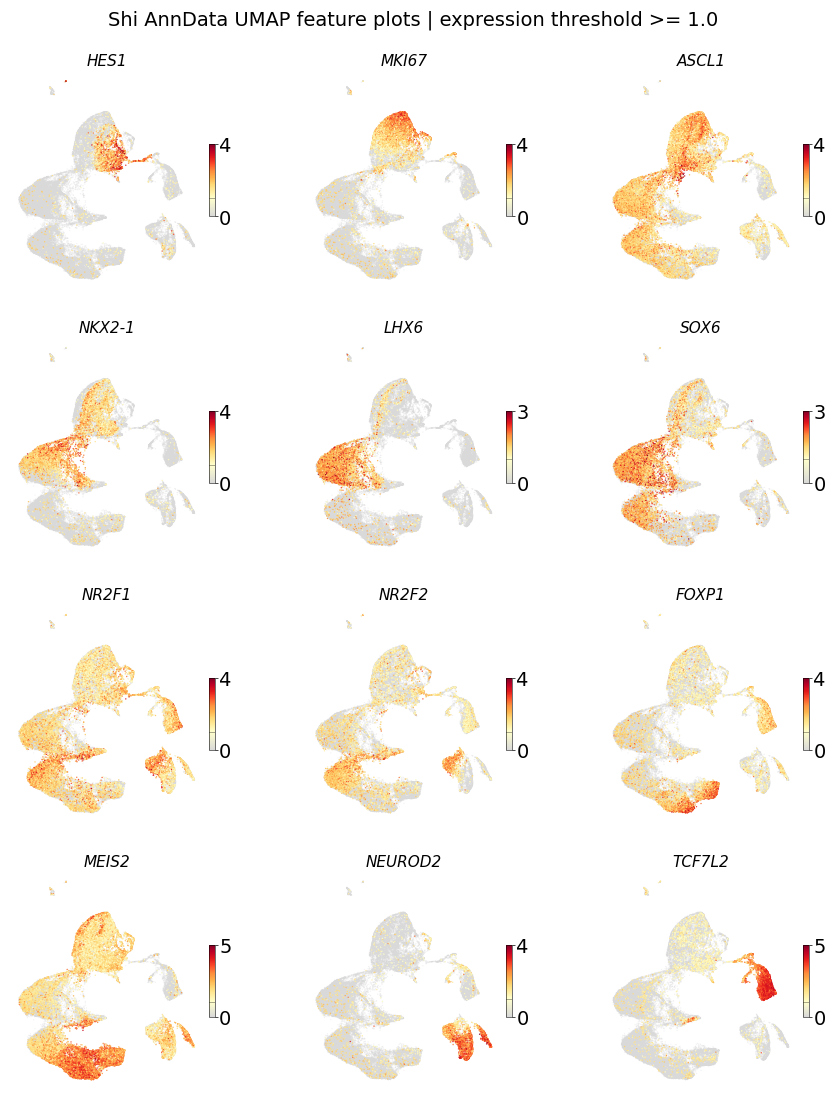

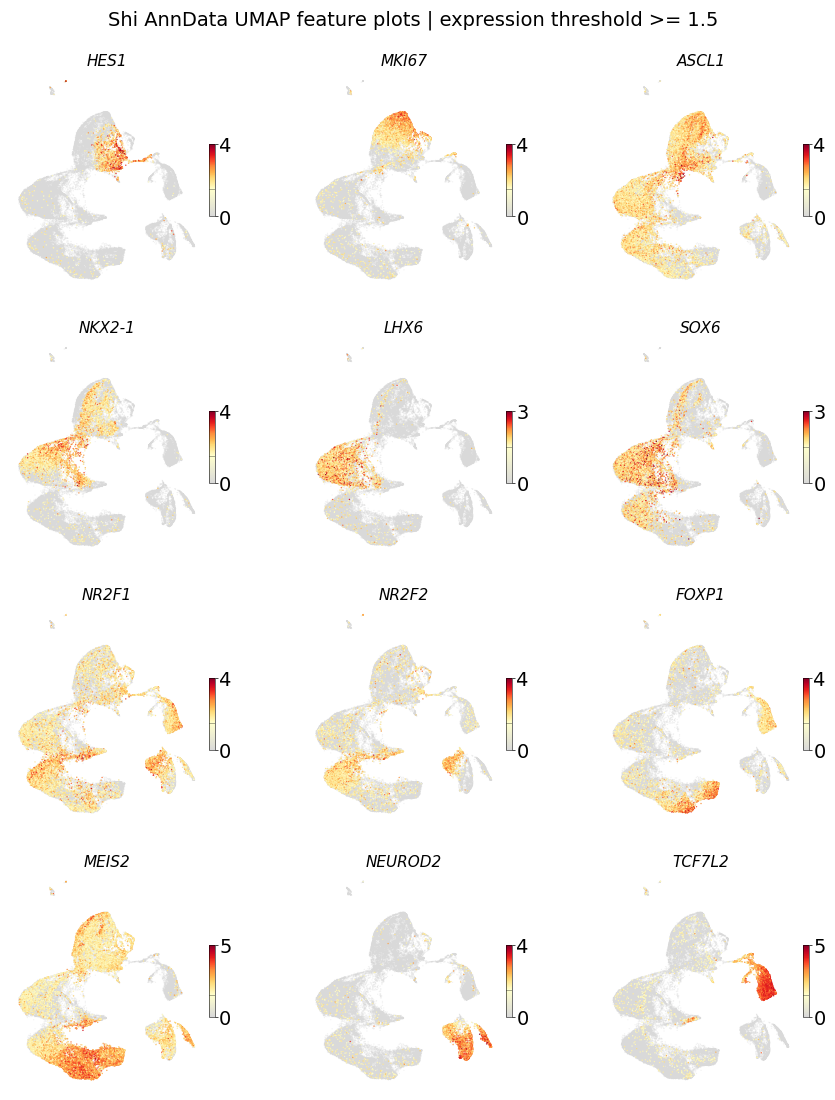

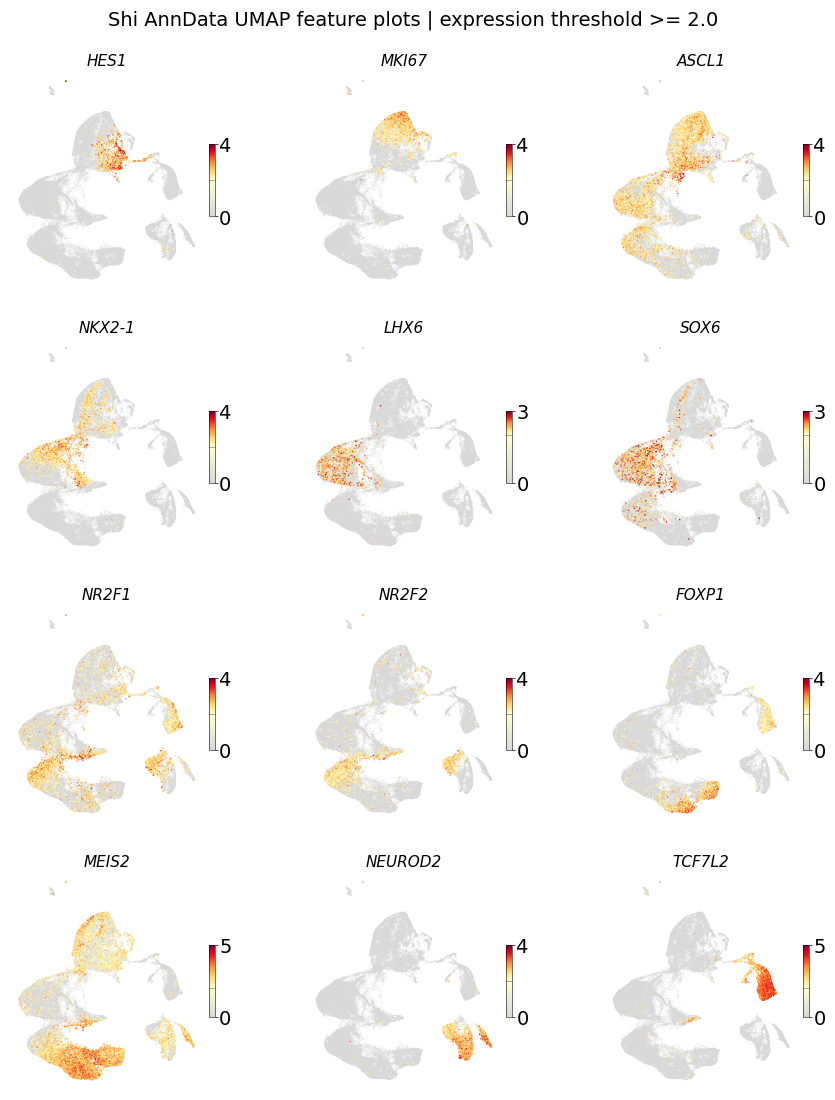

In [105]:
for threshold in [1.0, 1.5, 2.0]:
    fig, axes = plot_umap_feature_grid(
        shi,
        genes_to_plot,
        umap_key="X_umap",
        ncols=3,
        vmax_percentile=99,
        vmin_expression=threshold,
        cmap="YlOrRd",
        point_size_background=0.8,
        point_size_expression=1.0,
        background_alpha=0.35,
        expression_alpha=0.9,
        figsize_per_panel=(3.0, 2.8),
        colorbar_height="33%",
        colorbar_width="3%",
        colorbar_labelsize=14,
        show_threshold_line=True,
    )

    fig.suptitle(
        f"Shi AnnData UMAP feature plots | expression threshold >= {threshold}",
        fontsize=14,
        y=0.995,
    )

    plt.show()

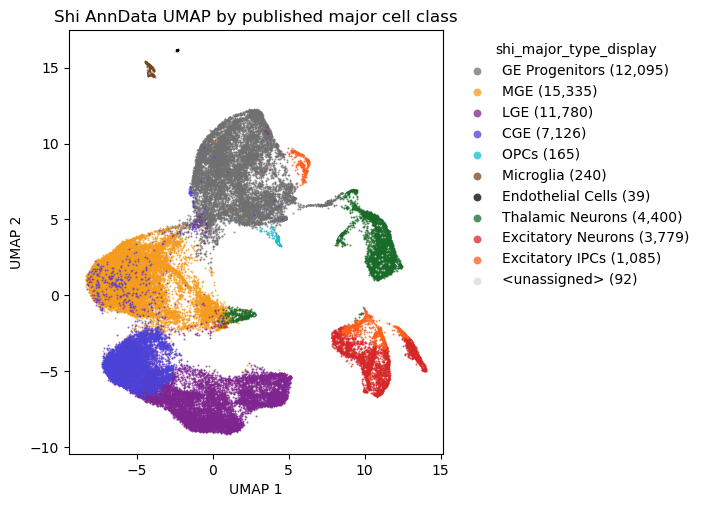

,display_label,color,n_cells
0,GE Progenitors,#707070,12095
1,MGE,#f59b1e,15335
2,LGE,#7F258F,11780
3,CGE,#4c42d8,7126
4,OPCs,#17becf,165
5,Microglia,#74461c,240
6,Endothelial Cells,#000000,39
7,Thalamic Neurons,#196b29,4400
8,Excitatory Neurons,#d62728,3779
9,Excitatory IPCs,#ff5e18,1085


,mapping_status,n_cells
0,mapped_unique,56044
1,ambiguous_duplicate_barcode,92


In [107]:
def add_shi_major_type_from_table_s2(adata, shi_s2):
    """
    Add published Shi major cell type labels from Table S2 into AnnData.obs.

    Uses Table S2 Cells like AAAC...-1 and maps them to AnnData IDs like
    AAAC...-GW09. Ambiguous duplicated GW12_02 barcodes are left unassigned.
    """
    out = adata

    suffix_to_sample = {
        "1": "GW09",
        "2": "GW12_01",
        "3": "GW13",
        "4": "GW16",
        "5": "GW18_01",
        "6": "GW18_02_CGE",
        "7": "GW18_02_LGE",
        "8": "GW18_02_MGE",
        "9": "GW12_02",
        "10": "GW12_02",
        "11": "GW12_02",
    }

    mapped = shi_s2.copy()
    mapped["barcode"] = mapped["Cells"].astype("string").str.replace(r"-\d+$", "", regex=True)
    mapped["s2_suffix"] = mapped["Cells"].astype("string").str.extract(r"-(\d+)$")[0]
    mapped["shi_sample_id"] = mapped["s2_suffix"].map(suffix_to_sample)
    mapped["candidate_cell_id"] = mapped["barcode"] + "-" + mapped["shi_sample_id"]
    mapped["published_major_type_clean"] = mapped["Major types"].astype("string").str.strip()

    candidate_counts = mapped["candidate_cell_id"].value_counts(dropna=False)
    mapped["candidate_is_unique"] = mapped["candidate_cell_id"].map(candidate_counts).eq(1)
    mapped["candidate_in_adata"] = mapped["candidate_cell_id"].isin(set(out.obs_names.astype(str)))

    safe_major_type_map = (
        mapped.loc[mapped["candidate_is_unique"] & mapped["candidate_in_adata"]]
        .set_index("candidate_cell_id")["published_major_type_clean"]
    )

    out.obs["shi_published_major_type"] = (
        pd.Series(out.obs_names.astype("string"), index=out.obs_names)
        .map(safe_major_type_map)
        .astype("category")
    )

    out.obs["shi_published_major_type_status"] = "unmapped"
    out.obs.loc[
        out.obs["shi_published_major_type"].notna(),
        "shi_published_major_type_status",
    ] = "mapped_unique"

    if "has_duplicated_raw_cell_id" in out.obs:
        out.obs.loc[
            out.obs["has_duplicated_raw_cell_id"].astype("string").eq("TRUE"),
            "shi_published_major_type_status",
        ] = "ambiguous_duplicate_barcode"

    out.obs["shi_published_major_type_status"] = (
        out.obs["shi_published_major_type_status"].astype("category")
    )

    return out, mapped


def add_shi_major_type_display_labels(adata):
    """
    Add figure-style display labels while preserving original Table S2 labels.
    """
    display_names = {
        "progenitor": "GE Progenitors",
        "MGE": "MGE",
        "LGE": "LGE",
        "CGE": "CGE",
        "OPC": "OPCs",
        "Microglia": "Microglia",
        "Endothelial": "Endothelial Cells",
        "Thalamic neurons": "Thalamic Neurons",
        "Excitatory neuron": "Excitatory Neurons",
        "Excitatory IPC": "Excitatory IPCs",
        "<unassigned>": "<unassigned>",
    }

    out = adata

    out.obs["shi_major_type_plot"] = (
        out.obs["shi_published_major_type"]
        .astype("string")
        .fillna("<unassigned>")
    )

    out.obs["shi_major_type_display"] = (
        out.obs["shi_major_type_plot"]
        .map(display_names)
        .fillna(out.obs["shi_major_type_plot"])
    )

    return out


shi = adatas["shi_2019_paper_qc"]

# Load Table S2 if it is not already loaded in the notebook.
shi_table_s2_path = (
    project_root
    / "reference"
    / "shi_2021_tables_s2_to_s9"
    / "science.abj6641_table_s2.xlsx"
)

shi_s2 = pd.read_excel(
    shi_table_s2_path,
    sheet_name="UMAP coordinates",
    header=1,
)

shi, shi_s2_mapped = add_shi_major_type_from_table_s2(shi, shi_s2)
shi = add_shi_major_type_display_labels(shi)

major_type_display_order = [
    "GE Progenitors",
    "MGE",
    "LGE",
    "CGE",
    "OPCs",
    "Microglia",
    "Endothelial Cells",
    "Thalamic Neurons",
    "Excitatory Neurons",
    "Excitatory IPCs",
    "<unassigned>",
]

major_type_display_colors = {
    "GE Progenitors": "#707070",
    "MGE": "#f59b1e",
    "LGE": "#7F258F",
    "CGE": "#4c42d8",
    "OPCs": "#17becf",
    "Microglia": "#74461c",
    "Endothelial Cells": "#000000",
    "Thalamic Neurons": "#196b29",
    "Excitatory Neurons": "#d62728",
    "Excitatory IPCs": "#ff5e18",
    "<unassigned>": "#d9d9d9",
}

shi.obs["shi_major_type_display"] = pd.Categorical(
    shi.obs["shi_major_type_display"],
    categories=[
        label
        for label in major_type_display_order
        if label in set(shi.obs["shi_major_type_display"].astype(str))
    ],
    ordered=True,
)

fig, ax = plot_adata_umap_by_category(
    shi,
    category="shi_major_type_display",
    color_map=major_type_display_colors,
    order=major_type_display_order,
    title="Shi AnnData UMAP by published major cell class",
    s=2,
    alpha=0.75,
)

plt.show()

major_type_color_check = pd.DataFrame(
    {
        "display_label": major_type_display_order,
        "color": [major_type_display_colors[label] for label in major_type_display_order],
        "n_cells": [
            int((shi.obs["shi_major_type_display"].astype("string") == label).sum())
            for label in major_type_display_order
        ],
    }
)

mapping_status_check = (
    shi.obs["shi_published_major_type_status"]
    .astype("string")
    .value_counts()
    .rename_axis("mapping_status")
    .reset_index(name="n_cells")
)

display(major_type_color_check)
display(mapping_status_check)

## UMAP Preview

These plots use `adata.obsm["X_umap"]` from the cached AnnData files. They do not touch the original Seurat objects.

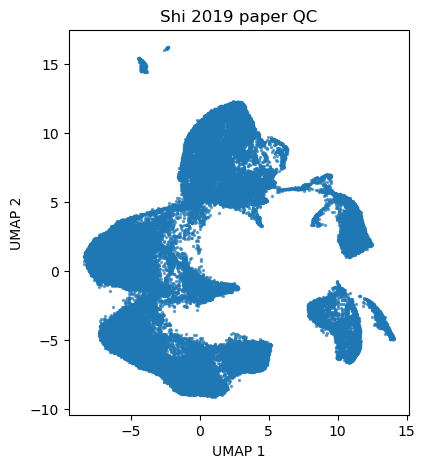

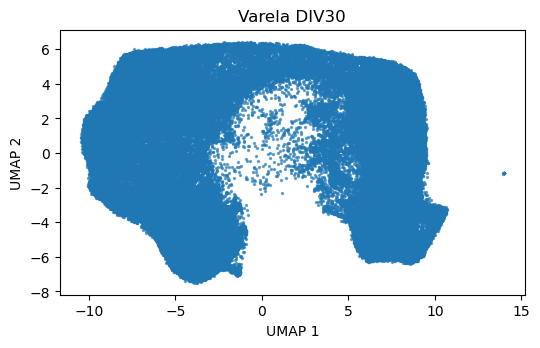

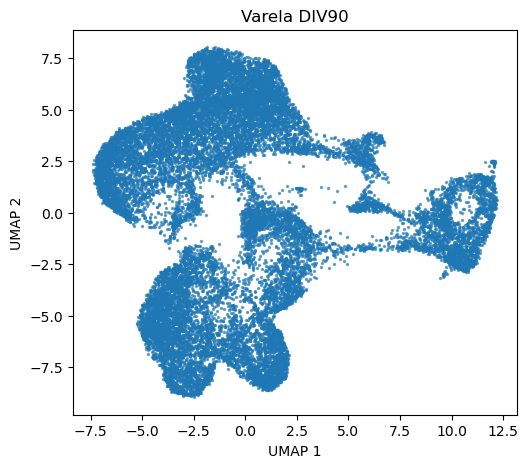

In [26]:
def plot_umap(adata, title, color_by=None, s=2, alpha=0.6):
    umap = adata.obsm["X_umap"]
    fig, ax = plt.subplots(figsize=(6, 5))
    if color_by and color_by in adata.obs:
        values = adata.obs[color_by].astype("category")
        codes = values.cat.codes
        scatter = ax.scatter(umap[:, 0], umap[:, 1], c=codes, s=s, alpha=alpha, cmap="tab20")
        ax.set_title(f"{title} colored by {color_by}")
    else:
        ax.scatter(umap[:, 0], umap[:, 1], s=s, alpha=alpha)
        ax.set_title(title)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_aspect("equal", adjustable="box")
    return fig, ax

plot_umap(adatas["shi_2019_paper_qc"], "Shi 2019 paper QC")
plot_umap(adatas["varela_div30"], "Varela DIV30")
plot_umap(adatas["varela_div90"], "Varela DIV90")
plt.show()

## Working With One Object

Use the `adatas` dictionary for downstream analysis. Keys are:

- `shi_2019_paper_qc`
- `varela_div30`
- `varela_div90`

In [27]:
adata = adatas["varela_div30"]
print(adata)
print("obs columns:", list(adata.obs.columns))
print("var columns:", list(adata.var.columns))

AnnData object with n_obs × n_vars = 90631 × 18082 backed at '/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/results/python_anndata/varela_div30.h5ad'
    obs: 'cell_id', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'CC.Difference', 'RNA_snn_res.0.2', 'seurat_clusters'
    var: 'feature_id'
    uns: 'conversion_manifest', 'seurat_assay', 'seurat_reduction', 'source_seurat_path'
    obsm: 'X_umap'
obs columns: ['cell_id', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'CC.Difference', 'RNA_snn_res.0.2', 'seurat_clusters']
var columns: ['feature_id']
